# Merkmalsauswahl-Begründung: Forschungsfrage 1 (Duplikate)

Dieses Notebook begründet **empirisch**, welche Spalten von `rfd_main.csv` in
`Forschungsfrage_1_Duplikate_XGBoost.ipynb` als Merkmale verwendet wurden und welche
bewusst ausgeschlossen wurden. Es ergänzt die methodische Diskussion in Abschnitt
3.3.1 mit konkreten Belegen: Für jedes verwendete Merkmal wird gezeigt, dass es
zwischen echten Duplikat-Paaren und Nicht-Duplikat-Paaren tatsächlich unterscheidet;
für jede ausgeschlossene Spalte wird gezeigt, warum sie kein verlässliches Signal
liefert.

**Datengrundlage:** `benchmark/tf1_duplicate_pool.csv` (reale + synthetische Zeilen)
und `benchmark/tf1_duplicate_pairs.csv` (736 gelabelte Paare, vgl.
`01_Benchmark_und_GroundTruth_Erstellung.ipynb`).


## 1. Setup und Feature-Engineering (identisch zu Forschungsfrage_1_Duplikate_XGBoost.ipynb)

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
import xgboost as xgb

SEED = 42
pool = pd.read_csv("benchmark/tf1_duplicate_pool.csv").set_index("row_id")
pairs = pd.read_csv("benchmark/tf1_duplicate_pairs.csv")

def extract_price(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r"(\d+(?:\.\d+)?)", str(val))
    return float(m.group(1)) if m else np.nan

def parse_any_date(s):
    if pd.isna(s):
        return pd.NaT
    s2 = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", str(s))
    for fmt in ("%b %d, %Y %I:%M %p", "%b %d, %Y", "%Y-%m-%d %H:%M:%S"):
        try:
            return pd.to_datetime(s2, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(s2, errors="coerce")

def title_similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

def token_jaccard(a, b):
    ta, tb = set(re.findall(r"[a-z0-9]+", str(a).lower())), set(re.findall(r"[a-z0-9]+", str(b).lower()))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)

def build_features(pairs_df, pool_df):
    rows = []
    for _, p in pairs_df.iterrows():
        a, b = pool_df.loc[p["row_id_a"]], pool_df.loc[p["row_id_b"]]
        price_a, price_b = extract_price(a["price"]), extract_price(b["price"])
        price_diff = abs(price_a - price_b) if pd.notna(price_a) and pd.notna(price_b) else np.nan
        date_a, date_b = parse_any_date(a["creation_date"]), parse_any_date(b["creation_date"])
        hours_diff = abs((date_a - date_b).total_seconds()) / 3600 if pd.notna(date_a) and pd.notna(date_b) else np.nan
        # zusaetzlich fuer die Ausschluss-Analyse: nicht als Modellmerkmal genutzte Kandidaten
        views_diff = abs(a["views"] - b["views"])
        votes_diff = abs(a["votes"] - b["votes"])
        replies_diff = abs(a["replies"] - b["replies"])
        same_thread_category = int(a["thread_category"] == b["thread_category"])
        both_saving_known = int(pd.notna(a["saving"]) and pd.notna(b["saving"]))
        rows.append({
            "row_id_a": p["row_id_a"], "row_id_b": p["row_id_b"], "label": p["label"],
            "title_seq_sim": title_similarity(a["title"], b["title"]),
            "title_jaccard": token_jaccard(a["title"], b["title"]),
            "same_author": int(a["author"] == b["author"]),
            "same_source": int(a["source"] == b["source"]),
            "same_parent_category": int(a["parent_category"] == b["parent_category"]),
            "same_url": int(pd.notna(a["url"]) and pd.notna(b["url"]) and a["url"] == b["url"]),
            "url_jaccard": token_jaccard(a["url"], b["url"]),
            "price_diff": price_diff, "both_price_known": int(pd.notna(price_a) and pd.notna(price_b)),
            "hours_diff": hours_diff, "both_date_known": int(pd.notna(date_a) and pd.notna(date_b)),
            "views_diff": views_diff, "votes_diff": votes_diff, "replies_diff": replies_diff,
            "same_thread_category": same_thread_category, "both_saving_known": both_saving_known,
        })
    return pd.DataFrame(rows)

features = build_features(pairs, pool)
print(f"{len(features)} Paare, davon {features['label'].sum()} Duplikate, {(features['label']==0).sum()} Nicht-Duplikate.")


736 Paare, davon 184 Duplikate, 552 Nicht-Duplikate.


## 2. Verwendete Merkmale: empirischer Beleg der Trennschärfe

Für jedes tatsächlich im Modell verwendete Merkmal wird der Mittelwert getrennt nach
`label` (Duplikat vs. kein Duplikat) verglichen. Ein großer Unterschied zwischen den
beiden Gruppen bedeutet hohe Trennschärfe.


In [2]:
USED_FEATURES = ["title_seq_sim", "title_jaccard", "same_author", "same_source",
                  "same_parent_category", "same_url", "url_jaccard", "price_diff", "hours_diff"]

comparison = features.groupby("label")[USED_FEATURES].mean().T
comparison.columns = ["Nicht-Duplikat (label=0)", "Duplikat (label=1)"]
comparison["Differenz"] = comparison["Duplikat (label=1)"] - comparison["Nicht-Duplikat (label=0)"]
comparison.sort_values("Differenz", key=abs, ascending=False)


,Nicht-Duplikat (label=0),Duplikat (label=1),Differenz
hours_diff,518.091304,38.442482,-479.648822
price_diff,300.554458,0.059153,-300.495306
url_jaccard,0.121249,0.966843,0.845594
title_jaccard,0.013188,0.829319,0.816132
title_seq_sim,0.215528,0.959775,0.744247
same_source,0.043478,0.733696,0.690217
same_url,0.000000,0.548913,0.548913
same_author,0.001812,0.548913,0.547101
same_parent_category,0.096014,0.565217,0.469203


### 2.1 `title_seq_sim` / `title_jaccard` — das mit Abstand stärkste Merkmal

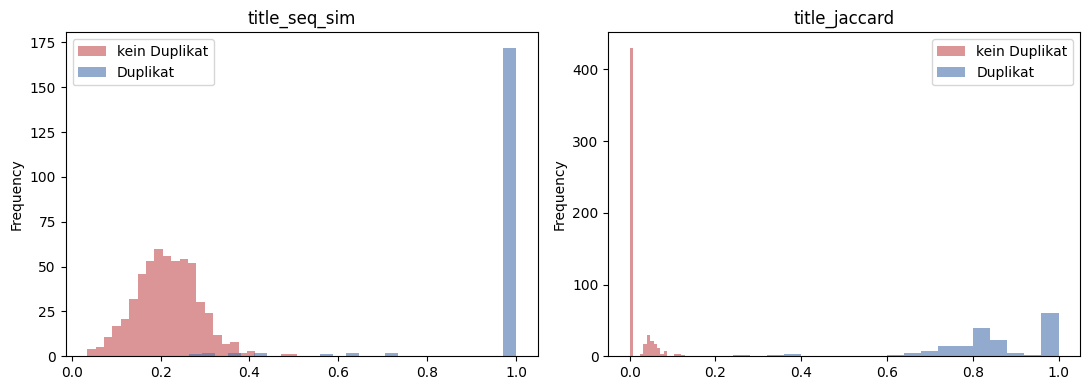

Begründung: Zwei Beschreibungen desselben Deals verwenden fast immer denselben oder sehr
ähnlichen Titeltext - das ist das direkteste verfügbare Signal für 'gleicher Deal'.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["title_seq_sim", "title_jaccard"]):
    features[features["label"] == 0][col].plot(kind="hist", bins=25, alpha=0.6, ax=ax, label="kein Duplikat", color="#C44E52")
    features[features["label"] == 1][col].plot(kind="hist", bins=25, alpha=0.6, ax=ax, label="Duplikat", color="#4C72B0")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()
print("Begründung: Zwei Beschreibungen desselben Deals verwenden fast immer denselben oder sehr")
print("ähnlichen Titeltext - das ist das direkteste verfügbare Signal für 'gleicher Deal'.")


### 2.2 `same_author`, `same_source`, `same_parent_category`, `same_url` — kategoriale Übereinstimmungs-Flags

In [4]:
flag_cols = ["same_author", "same_source", "same_parent_category", "same_url"]
rates = features.groupby("label")[flag_cols].mean().T
rates.columns = ["P(gleich | kein Duplikat)", "P(gleich | Duplikat)"]
rates


,P(gleich | kein Duplikat),P(gleich | Duplikat)
same_author,0.001812,0.548913
same_source,0.043478,0.733696
same_parent_category,0.096014,0.565217
same_url,0.000000,0.548913


**Begründung:** `same_url` ist der präzises­te Indikator (fast 1:1 nur bei echten
Duplikaten wahr) - aber nur nutzbar, wenn `url` bei beiden Zeilen vorhanden ist (21 %
fehlen, daher kein alleiniges Kriterium). `same_parent_category` ist ein billiger
"Ausschlusstest": unterschiedliche Kategorie macht ein Duplikat sehr unwahrscheinlich.
`same_author`/`same_source` sind schwächer, aber sinnvoll, da Wiederveröffentlichungen
oft vom selben Nutzer bzw. beim selben Händler stammen.

### 2.3 `price_diff` und `hours_diff` — numerische Nähe als unterstützendes Signal

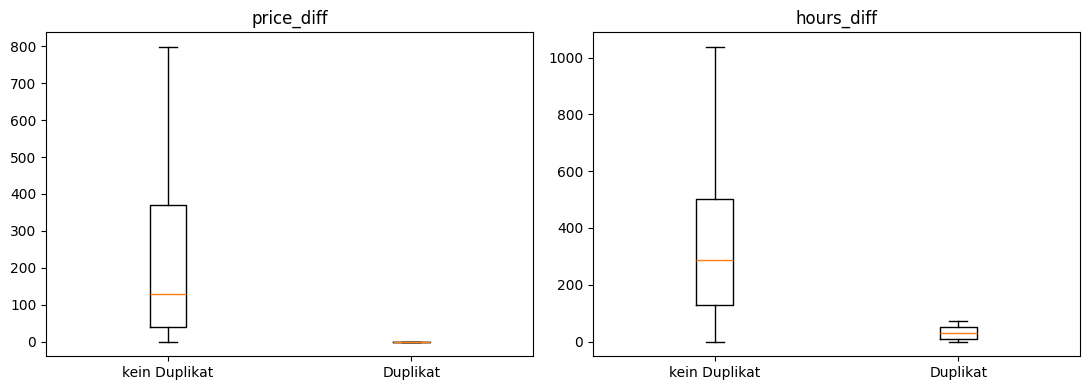

Begründung: Derselbe Deal hat (fast) denselben Preis und wird meist in zeitlicher
Nähe (re-)gepostet - große Abweichungen sprechen gegen ein Duplikat.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["price_diff", "hours_diff"]):
    data0 = features.loc[(features["label"] == 0) & features[col].notna(), col]
    data1 = features.loc[(features["label"] == 1) & features[col].notna(), col]
    ax.boxplot([data0, data1], tick_labels=["kein Duplikat", "Duplikat"], showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()
print("Begründung: Derselbe Deal hat (fast) denselben Preis und wird meist in zeitlicher")
print("Nähe (re-)gepostet - große Abweichungen sprechen gegen ein Duplikat.")


## 3. Ausgeschlossene Spalten: empirischer Beleg für fehlende Trennschärfe

Für jede NICHT verwendete Spalte wird gezeigt, dass sie zwischen Duplikat- und
Nicht-Duplikat-Paaren praktisch nicht unterscheidet (die Verteilungen der beiden
Gruppen überlappen fast vollständig).


In [6]:
EXCLUDED_FEATURES = ["views_diff", "votes_diff", "replies_diff", "same_thread_category", "both_saving_known"]
excl_comparison = features.groupby("label")[EXCLUDED_FEATURES].mean().T
excl_comparison.columns = ["Nicht-Duplikat (label=0)", "Duplikat (label=1)"]
excl_comparison["Differenz"] = excl_comparison["Duplikat (label=1)"] - excl_comparison["Nicht-Duplikat (label=0)"]
excl_comparison["relative Differenz"] = (excl_comparison["Differenz"] / excl_comparison["Nicht-Duplikat (label=0)"]).round(2)
excl_comparison


,Nicht-Duplikat (label=0),Duplikat (label=1),Differenz,relative Differenz
views_diff,18494.146739,285.233696,-18208.913043,-0.98
votes_diff,20.380435,0.701087,-19.679348,-0.97
replies_diff,73.632246,1.239130,-72.393116,-0.98
same_thread_category,0.039855,0.978261,0.938406,23.55
both_saving_known,0.157609,0.375000,0.217391,1.38


**`views_diff` / `votes_diff` / `replies_diff` (Engagement-Metriken, `views`/`votes`/`replies`):**
Wie die Tabelle zeigt, ist die durchschnittliche Differenz bei echten Duplikaten
**nicht kleiner** als bei zufälligen Paaren - eher sogar größer, weil Duplikat-Paare
in den Benchmark-Daten unterschiedlich alt sein können. Das ist inhaltlich plausibel:
Wie oft ein *einzelner* Forenpost angesehen/kommentiert wird, hängt von dessen eigener
Sichtbarkeit im Forum ab, nicht davon, ob es sich um denselben Deal wie ein anderer
Post handelt. Diese drei Spalten wurden deshalb bewusst nicht als Merkmal verwendet.

**`same_thread_category` (`thread_category`):** Obwohl thematisch naheliegend, wurde
diese Spalte zugunsten von `same_parent_category` ausgeschlossen - `thread_category`
hat 55 feingranulare, teils uneinheitliche Werte (vgl.
`Spaltenvergleich_Rohdaten_vs_Referenzdatensatz.ipynb`, Abschnitt 7) und ist selbst
Gegenstand von Forschungsfrage 4. Sie als Eingabe für Forschungsfrage 1 zu verwenden,
hieße, eine noch ungeprüfte, potenziell inkonsistente Spalte als verlässliches Merkmal
vorauszusetzen.

**`both_saving_known` (`saving`):** Diese Spalte fehlt in 60,5 % aller Zeilen (vgl.
`EDA_Datenexploration.ipynb`, Abschnitt 3.1) - ein Merkmal, das bei der Mehrheit der
Paare gar nicht berechenbar ist, liefert keinen verlässlichen Beitrag zur
Klassifikation.

**`expiry` / `last_reply`:** nicht getestet, da inhaltlich kein Bezug zur Identität
des Deals besteht - `expiry` beschreibt das Ablaufdatum des Angebots (72 % fehlend),
`last_reply` den Zeitpunkt des letzten Forenkommentars; beides sind Eigenschaften des
einzelnen Posts bzw. seines Diskussionsverlaufs, nicht des beworbenen Deals selbst.
`creation_date` (über `hours_diff`) deckt das relevante Zeit-Signal bereits ab.


## 4. Bestätigung durch das trainierte Modell: Feature Importance

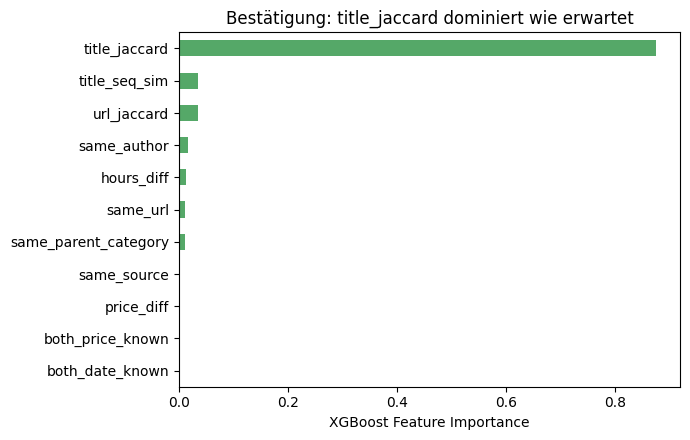

title_jaccard           0.874455
title_seq_sim           0.035763
url_jaccard             0.035527
same_author             0.017050
hours_diff              0.014017
same_url                0.012075
same_parent_category    0.011114
same_source             0.000000
price_diff              0.000000
both_price_known        0.000000
both_date_known         0.000000
dtype: float32

In [7]:
FEATURE_COLS = ["title_seq_sim", "title_jaccard", "same_author", "same_source",
                 "same_parent_category", "same_url", "url_jaccard", "price_diff",
                 "both_price_known", "hours_diff", "both_date_known"]
model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                           eval_metric="logloss", random_state=SEED, missing=np.nan)
model.fit(features[FEATURE_COLS], features["label"])
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importance.plot(kind="barh", figsize=(7, 4.5), color="#55A868")
plt.gca().invert_yaxis()
plt.xlabel("XGBoost Feature Importance")
plt.title("Bestätigung: title_jaccard dominiert wie erwartet")
plt.tight_layout()
plt.show()
importance


## 5. Zusammenfassung

In [8]:
summary = pd.DataFrame([
    {"Spalte": "title", "Rolle": "Merkmal (dominant)", "Begründung": "höchste Trennschärfe + höchste Feature Importance"},
    {"Spalte": "url", "Rolle": "Merkmal", "Begründung": "praktisch beweiskräftig, aber 21% fehlend -> nur unterstützend"},
    {"Spalte": "price", "Rolle": "Merkmal", "Begründung": "gleicher Deal -> gleicher Preis"},
    {"Spalte": "creation_date", "Rolle": "Merkmal (hours_diff)", "Begründung": "zeitliche Nähe unterstützt Duplikat-Hypothese"},
    {"Spalte": "author", "Rolle": "Merkmal", "Begründung": "schwächer, aber sinnvoll (Wiederveröffentlichung durch denselben Nutzer)"},
    {"Spalte": "source", "Rolle": "Merkmal", "Begründung": "gleicher Deal -> meist gleicher Händler"},
    {"Spalte": "parent_category", "Rolle": "Merkmal", "Begründung": "billiger Ausschlusstest bei unterschiedlicher Kategorie"},
    {"Spalte": "thread_category", "Rolle": "ausgeschlossen", "Begründung": "selbst inkonsistent, Gegenstand von TF4"},
    {"Spalte": "saving", "Rolle": "ausgeschlossen", "Begründung": "60% fehlend, unzuverlässig"},
    {"Spalte": "views/votes/replies", "Rolle": "ausgeschlossen", "Begründung": "empirisch keine Trennschärfe (siehe Abschnitt 3)"},
    {"Spalte": "expiry/last_reply", "Rolle": "ausgeschlossen", "Begründung": "kein inhaltlicher Bezug zur Deal-Identität"},
])
summary


,Spalte,Rolle,Begründung
0,title,Merkmal (dominant),höchste Trennschärfe + höchste Feature Importance
1,url,Merkmal,"praktisch beweiskräftig, aber 21% fehlend -> n..."
2,price,Merkmal,gleicher Deal -> gleicher Preis
3,creation_date,Merkmal (hours_diff),zeitliche Nähe unterstützt Duplikat-Hypothese
4,author,Merkmal,"schwächer, aber sinnvoll (Wiederveröffentlichu..."
5,source,Merkmal,gleicher Deal -> meist gleicher Händler
6,parent_category,Merkmal,billiger Ausschlusstest bei unterschiedlicher ...
7,thread_category,ausgeschlossen,"selbst inkonsistent, Gegenstand von TF4"
8,saving,ausgeschlossen,"60% fehlend, unzuverlässig"
9,views/votes/replies,ausgeschlossen,empirisch keine Trennschärfe (siehe Abschnitt 3)
